In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import copy
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

In [16]:
CONFIG = {
    'pop_size': 20,           
    'generations': 10,       
    'elite_size': 3,          
    'max_epochs': 5,         
    'early_stop_patience': 5, 
    'min_layers': 1,          
    'max_layers': 5,          
    'min_neurons': 16,        
    'max_neurons': 256,       
    'activations': ['relu', 'tanh', 'sigmoid'],
    'reg_min': 1e-5,          
    'reg_max': 1e-2,         
    'penalty_layer': 0.03,   
    'penalty_param': 1e-6,   
    'mut_prob': 0.3,         
    'input_dim': 78,          
    'output_dim': 2,         
    'batch_size': 32
}

ACT_MAP = {'relu': nn.ReLU, 'tanh': nn.Tanh, 'sigmoid': nn.Sigmoid}

In [17]:
class DynamicNet(nn.Module):
    def __init__(self, layers_config, input_dim, output_dim, reg_lambda):
        super().__init__()
        self.reg_lambda = reg_lambda
        modules = []
        prev_dim = input_dim
        for neurons, act_name in layers_config:
            modules.append(nn.Linear(prev_dim, neurons))
            modules.append(ACT_MAP[act_name]())
            prev_dim = neurons
        modules.append(nn.Linear(prev_dim, output_dim))
        self.network = nn.Sequential(*modules)

    def forward(self, x):
        return self.network(x)

    def count_params(self):
        return sum(p.numel() for p in self.parameters())

In [18]:
def evaluate_individual(individual, train_loader, val_loader, cfg):
    model = DynamicNet(individual['layers'], cfg['input_dim'], cfg['output_dim'], individual['reg'])
    optimizer = optim.Adam(model.parameters(), weight_decay=individual['reg'])
    criterion = nn.CrossEntropyLoss()

    best_val_acc = 0.0
    patience_counter = 0

    for epoch in range(cfg['max_epochs']):
        model.train()
        for X, y in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(X), y)
            loss.backward()
            optimizer.step()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for X, y in val_loader:
                preds = torch.argmax(model(X), dim=1)
                correct += (preds == y).sum().item()
                total += y.size(0)
        val_acc = correct / total

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= cfg['early_stop_patience']:
            break

    n_layers = len(individual['layers'])
    n_params = model.count_params()
    penalty = cfg['penalty_layer'] * n_layers + cfg['penalty_param'] * np.log1p(n_params)
    fitness = best_val_acc - penalty

    return fitness, best_val_acc, n_params

In [19]:
def create_individual(cfg):
    n_layers = random.randint(cfg['min_layers'], cfg['max_layers'])
    layers = [
        (random.randint(cfg['min_neurons'], cfg['max_neurons']), random.choice(cfg['activations']))
        for _ in range(n_layers)
    ]
    reg = 10 ** random.uniform(np.log10(cfg['reg_min']), np.log10(cfg['reg_max']))
    return {'layers': layers, 'reg': reg}

def crossover(p1, p2, cfg):
    child_layers = []
    min_len = min(len(p1['layers']), len(p2['layers']))
    
    for i in range(min_len):
        child_layers.append(random.choice([p1['layers'][i], p2['layers'][i]]))
        
    longer = p1['layers'] if len(p1['layers']) > len(p2['layers']) else p2['layers']
    for i in range(min_len, len(longer)):
        if random.random() < 0.5 and len(child_layers) < cfg['max_layers']:
            child_layers.append(longer[i])

    while len(child_layers) < cfg['min_layers']:
        child_layers.append((random.randint(cfg['min_neurons'], cfg['max_neurons']), random.choice(cfg['activations'])))

    child_reg = 10 ** np.mean([np.log10(p1['reg']), np.log10(p2['reg'])])
    return {'layers': child_layers, 'reg': child_reg}

def mutate(ind, cfg):
    if random.random() >= cfg['mut_prob']:
        return ind
        
    mut_type = random.choice(['add', 'remove', 'neuron', 'act', 'reg'])
    if mut_type == 'add' and len(ind['layers']) < cfg['max_layers']:
        n, a = random.randint(cfg['min_neurons'], cfg['max_neurons']), random.choice(cfg['activations'])
        ind['layers'].insert(random.randint(0, len(ind['layers'])), (n, a))
    elif mut_type == 'remove' and len(ind['layers']) > cfg['min_layers']:
        ind['layers'].pop(random.randint(0, len(ind['layers'])-1))
    elif mut_type == 'neuron':
        idx = random.randint(0, len(ind['layers'])-1)
        old_n, act = ind['layers'][idx]
        new_n = max(cfg['min_neurons'], min(cfg['max_neurons'], old_n + random.randint(-32, 32)))
        ind['layers'][idx] = (new_n, act)
    elif mut_type == 'act':
        idx = random.randint(0, len(ind['layers'])-1)
        n, _ = ind['layers'][idx]
        ind['layers'][idx] = (n, random.choice(cfg['activations']))
    elif mut_type == 'reg':
        log_r = np.log10(ind['reg']) + random.gauss(0, 0.3)
        ind['reg'] = 10 ** max(np.log10(cfg['reg_min']), min(np.log10(cfg['reg_max']), log_r))
    return ind

In [20]:
def run_evolution(train_loader, val_loader, cfg):
    population = [create_individual(cfg) for _ in range(cfg['pop_size'])]
    history = []

    for gen in range(1, cfg['generations'] + 1):
        results = [evaluate_individual(ind, train_loader, val_loader, cfg) for ind in population]
        fitnesses = [r[0] for r in results]
        
        paired = sorted(zip(population, results), key=lambda x: x[1][0], reverse=True)
        population, results = zip(*paired)
        population = list(population)
        
        best_fit, best_acc, best_params = results[0]
        best_layers = len(population[0]['layers'])
        print(f"Поколение {gen}/{cfg['generations']} | Фитнес: {round(best_fit, 4)} | Acc: {round(best_acc, 3)} | Слои: {best_layers} | Параметры: {best_params}")
        history.append(results[0])

        next_population = list(population[:cfg['elite_size']])

        while len(next_population) < cfg['pop_size']:
            i, j = random.sample(range(cfg['pop_size']), 2)
            p1 = population[i] if results[i][0] > results[j][0] else population[j]
            i, j = random.sample(range(cfg['pop_size']), 2)
            p2 = population[i] if results[i][0] > results[j][0] else population[j]
            
            child = crossover(copy.deepcopy(p1), copy.deepcopy(p2), cfg)
            child = mutate(child, cfg)
            next_population.append(child)
            
        population = next_population

    return population[0], history


In [21]:
torch.manual_seed(42)

data = pd.read_csv("D:/PythonWork/OldZmiy/AppleModel/data/cyber_attacks.csv")

y = data[' Label']
X = data.drop([' Label'], axis=1)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.23, random_state=42)

X_train = torch.tensor(X_train[:5000].to_numpy(), dtype=torch.float32)
X_val = torch.tensor(X_val[:500].to_numpy(), dtype=torch.float32)

y_train = torch.tensor(y_train[:5000].to_numpy().astype(int), dtype=torch.long)
y_val   = torch.tensor(y_val[:500].to_numpy().astype(int), dtype=torch.long)

CONFIG['input_dim'] = X_train.shape[1]  
CONFIG['output_dim'] = len(np.unique(y_train))  

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=CONFIG['batch_size'], shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=CONFIG['batch_size'])

best_individual, hist = run_evolution(train_loader, val_loader, CONFIG)

print("Лучшая найденная архитектура:")
print(f"Слои: {best_individual['layers']}")
print(f"Регуляризация: {round(best_individual['reg'], 2)}")

final_model = DynamicNet(best_individual['layers'], CONFIG['input_dim'], CONFIG['output_dim'], best_individual['reg'])
print(f"Обучаемых параметров: {final_model.count_params()}")

Поколение 1/10 | Фитнес: 0.934 | Acc: 0.964 | Слои: 1 | Параметры: 2954
Поколение 2/10 | Фитнес: 0.948 | Acc: 0.978 | Слои: 1 | Параметры: 2954
Поколение 3/10 | Фитнес: 0.94 | Acc: 0.97 | Слои: 1 | Параметры: 16320
Поколение 4/10 | Фитнес: 0.954 | Acc: 0.984 | Слои: 1 | Параметры: 16320
Поколение 5/10 | Фитнес: 0.948 | Acc: 0.978 | Слои: 1 | Параметры: 2954
Поколение 6/10 | Фитнес: 0.952 | Acc: 0.982 | Слои: 1 | Параметры: 16320
Поколение 7/10 | Фитнес: 0.954 | Acc: 0.984 | Слои: 1 | Параметры: 16320
Поколение 8/10 | Фитнес: 0.954 | Acc: 0.984 | Слои: 1 | Параметры: 16320
Поколение 9/10 | Фитнес: 0.95 | Acc: 0.98 | Слои: 1 | Параметры: 2954
Поколение 10/10 | Фитнес: 0.95 | Acc: 0.98 | Слои: 1 | Параметры: 2954
Лучшая найденная архитектура:
Слои: [(36, 'relu')]
Регуляризация: 0.0
Обучаемых параметров: 2954


In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

class MyClassifier(nn.Module):
    def __init__(self, input_size, hidden_sizes, num_classes):
        super(MyClassifier, self).__init__()
        layers = []
        prev_size = input_size
        
        for h_size in hidden_sizes:
            layers.extend([
                nn.Linear(prev_size, h_size),
                nn.BatchNorm1d(h_size),
                nn.LeakyReLU(),
                nn.Dropout(0.5) 
            ])
            prev_size = h_size
        
        layers.append(nn.Linear(prev_size, num_classes))
        self.layers = nn.Sequential(*layers)
    
    def forward(self, x):
        logits = self.layers(x)
        probs = nn.functional.softmax(logits, dim=-1)
        return probs

Epoch 1, Loss: 0.7450
Epoch 2, Loss: 0.7393
Epoch 3, Loss: 0.7254
Epoch 4, Loss: 0.6815
Epoch 5, Loss: 0.6446
Epoch 6, Loss: 0.6365
Epoch 7, Loss: 0.6227
Epoch 8, Loss: 0.6137
Epoch 9, Loss: 0.5759
Epoch 10, Loss: 0.5830


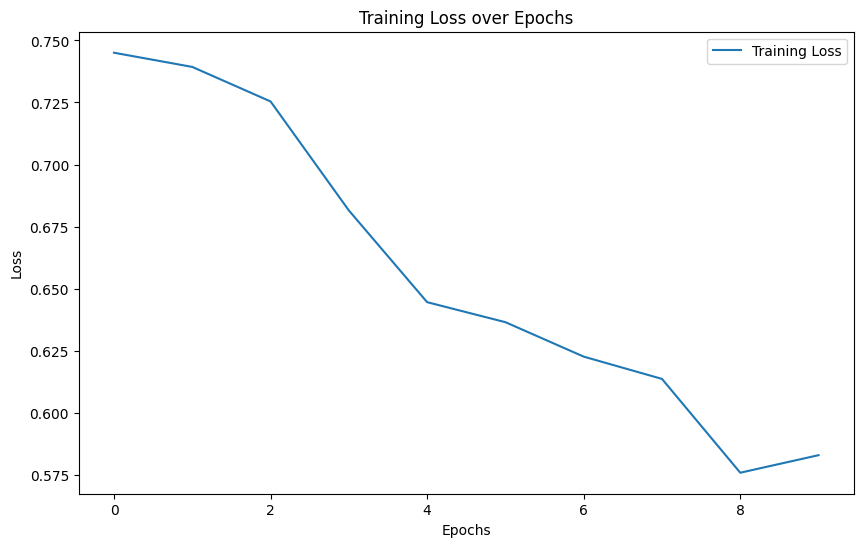

In [24]:
model = MyClassifier(input_size=79, hidden_sizes=[128, 64, 32, 16], num_classes=2)
criterion = nn.CrossEntropyLoss()
optimizer = optim.RMSprop(model.parameters(), lr=0.1)

losses = [] 

for epoch in range(10):
    sum_loss = 0.0
    for inputs, targets in train_loader:
        optimizer.zero_grad()
        
        outputs = model(inputs)

        loss = criterion(outputs, targets)
  
        loss.backward()

        optimizer.step()

        sum_loss += loss.item()
    
    med_loss = sum_loss / len(train_loader)
    print(f'Epoch {epoch+1}, Loss: {med_loss:.4f}')
    losses.append(med_loss)

plt.figure(figsize=(10, 6))
plt.plot(range(len(losses)), losses, label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss over Epochs")
plt.legend()
plt.show()

In [26]:
from sklearn.metrics import classification_report
import numpy as np

model.eval()  

true_labels = []
predicted_labels = []

with torch.no_grad(): 
    for inputs, targets in val_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)  
        
        true_labels.extend(targets.cpu().numpy())
        predicted_labels.extend(predicted.cpu().numpy())

true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

report = classification_report(true_labels, predicted_labels)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.44      0.62       218
           1       0.70      1.00      0.82       282

    accuracy                           0.76       500
   macro avg       0.85      0.72      0.72       500
weighted avg       0.83      0.76      0.73       500

